In [1]:
# ================================
# Cell 1: Import Required Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("All libraries loaded successfully!")

from google.colab import files
files.upload()

All libraries loaded successfully!


Saving Social_Network_Ads.csv to Social_Network_Ads (1).csv


{'Social_Network_Ads (1).csv': b'User ID,Gender,Age,EstimatedSalary,Purchased\n15624510,Male,19,19000,No\n15810944,Male,35,20000,No\n15668575,Female,,43000,No\n15603246,Female,27,57000,No\n15804002,Male,19,76000,No\n15728773,Male,27,58000,No\n15598044,Female,27,84000,No\n15694829,Female,32,150000,Yes\n15600575,Male,25,33000,No\n15727311,Female,35,65000,No\n15570769,Female,26,80000,No\n15606274,Female,26,52000,No\n15746139,Male,20,86000,No\n15704987,Male,32,18000,No\n15628972,Male,18,82000,No\n15697686,Male,29,80000,No\n15733883,Male,47,25000,Yes\n15617482,Male,45,26000,Yes\n15704583,Male,46,28000,Yes\n15621083,Female,48,29000,Yes\n15649487,Male,45,22000,Yes\n15736760,Female,47,49000,Yes\n15714658,Male,48,41000,Yes\n15599081,Female,45,22000,Yes\n15705113,Male,46,23000,Yes\n15631159,Male,47,20000,Yes\n15792818,Male,49,28000,Yes\n15633531,Female,47,30000,Yes\n15744529,Male,29,43000,No\n15669656,Male,31,18000,No\n15581198,Male,31,74000,No\n15729054,Female,27,137000,Yes\n15573452,Female,21,

In [2]:
# ================================
# Cell 2: Load and Clean Dataset
# ================================

df = pd.read_csv("Social_Network_Ads.csv")

# Rename column
df.rename(columns={"User ID": "ID"}, inplace=True)

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Convert categorical values to numbers
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

if df['Purchased'].dtype == 'object':
    df["Purchased"] = df["Purchased"].map({"Yes": 1, "No": 0})

print("Data cleaning complete")

df.head()

Data cleaning complete


,ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19.000000,19000,0
1,15810944,1,35.000000,20000,0
2,15668575,0,37.684211,43000,0
3,15603246,0,27.000000,57000,0
4,15804002,1,19.000000,76000,0


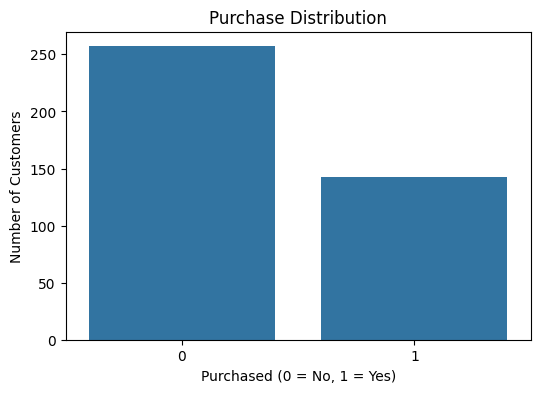

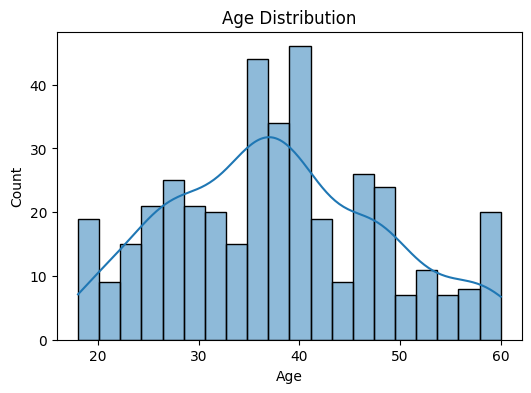

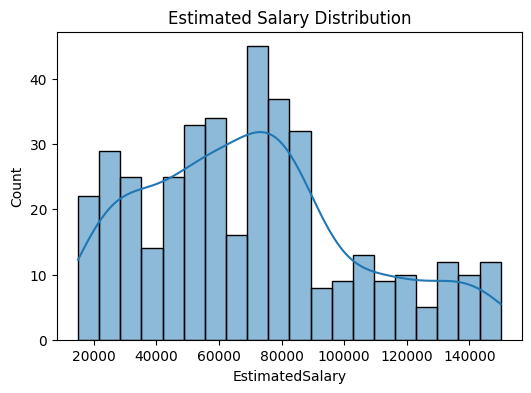

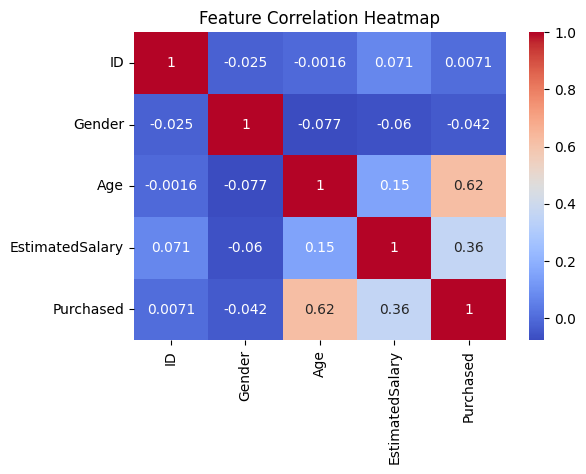

In [3]:
# ================================
# Cell 3: Exploratory Data Analysis
# ================================

# Purchase distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Purchased", data=df)
plt.title("Purchase Distribution")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Salary distribution
plt.figure(figsize=(6,4))
sns.histplot(df["EstimatedSalary"], bins=20, kde=True)
plt.title("Estimated Salary Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

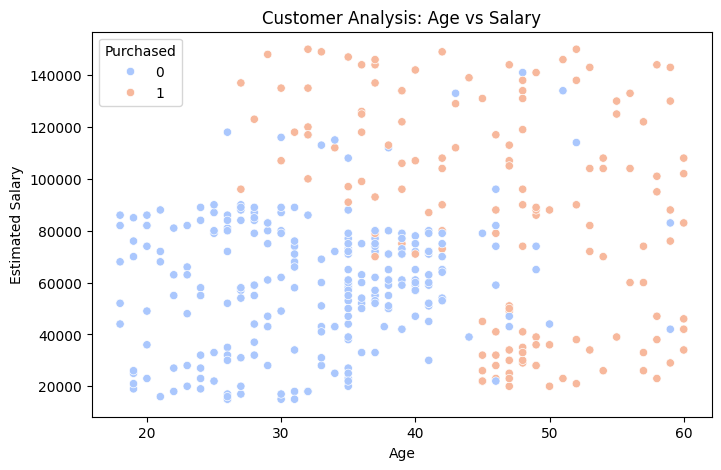

In [4]:
# ================================
# Cell 4: Customer Visualization
# ================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="EstimatedSalary",
    hue="Purchased",
    palette="coolwarm",
    data=df
)

plt.title("Customer Analysis: Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.show()

In [5]:
# ================================
# Cell 5: Feature Selection & Scaling
# ================================

X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data prepared and scaled successfully!")

Data prepared and scaled successfully!


In [6]:
# ================================
# Cell 6: Train and Evaluate Models
# ================================

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("----- Logistic Regression Results -----")

print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

# Cross validation
log_cv = cross_val_score(log_model, X_train, y_train, cv=5)

print("Cross Validation Scores:", log_cv)
print("Cross Validation Accuracy:", log_cv.mean())

# KNN with hyperparameter tuning
param_grid = {'n_neighbors': [3,5,7,9]}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

knn_model = grid.best_estimator_

knn_pred = knn_model.predict(X_test)

print("\n----- KNN Results -----")

print("Best K:", grid.best_params_)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))


# Select best model
log_acc = accuracy_score(y_test, log_pred)
knn_acc = accuracy_score(y_test, knn_pred)

if log_acc > knn_acc:
    final_model = log_model
    print("\nSelected Model: Logistic Regression")
else:
    final_model = knn_model
    print("\nSelected Model: KNN")

----- Logistic Regression Results -----
Accuracy: 0.8875
Precision: 0.9130434782608695
Recall: 0.75
F1 Score: 0.8235294117647058
Confusion Matrix:
[[50  2]
 [ 7 21]]
Cross Validation Scores: [0.796875 0.859375 0.828125 0.78125  0.8125  ]
Cross Validation Accuracy: 0.815625

----- KNN Results -----
Best K: {'n_neighbors': 7}
Accuracy: 0.925
Precision: 0.8666666666666667
Recall: 0.9285714285714286
F1 Score: 0.896551724137931
Confusion Matrix:
[[48  4]
 [ 2 26]]

Selected Model: KNN


In [7]:
# ================================
# Cell 7: Prediction using Customer ID
# ================================

print("\n===== Customer Purchase Prediction System =====")

customer_id = int(input("Enter Customer ID: "))

row = df[df["ID"] == customer_id]

if row.empty:
    print("Customer not found!")

else:
    features = row[['Gender','Age','EstimatedSalary']].values

    scaled_features = scaler.transform(features)

    prediction = final_model.predict(scaled_features)

    print("\nCustomer Details:")
    print(row[['Gender','Age','EstimatedSalary']])

    print("\nPrediction Result:")

    if prediction[0] == 1:
        print(f"Customer {customer_id} WILL purchase the product")
    else:
        print(f"Customer {customer_id} WILL NOT purchase the product")


===== Customer Purchase Prediction System =====
Enter Customer ID: 15804002

Customer Details:
   Gender   Age  EstimatedSalary
4       1  19.0            76000

Prediction Result:
Customer 15804002 WILL NOT purchase the product


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
